# Zadanie: regresja logistyczna na zbiorze breast_cancer


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score,
average_precision_score,
brier_score_loss, confusion_matrix,
roc_curve)

# 1) Dane
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

# 2) Podział
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25,
stratify=y, random_state=42)

# 3) Pipeline: standaryzacja + LR (L2)
base = Pipeline([
("sc", StandardScaler()),
("lr", LogisticRegression(max_iter=500,
class_weight="balanced", solver="lbfgs"))
])
base.fit(Xtr, ytr)
p_base = base.predict_proba(Xte)[:, 1] # prawdopodobieństwa p

# 4) Prawdopodobieństwo vs. szansa vs. logit
def odds(p): return p / (1 - p)
def logit(p): return np.log(p / (1 - p))
ex = pd.DataFrame({"p": p_base[:5],
"odds": odds(p_base[:5]),
"logit": logit(p_base[:5])})
print("\nProb/odds/logit (pierwsze 5):\n", ex.round(4))


Prob/odds/logit (pierwsze 5):
         p     odds   logit
0  0.9547  21.0763  3.0481
1  0.0003   0.0003 -8.2040
2  0.4633   0.8632 -0.1471
3  0.9078   9.8412  2.2866
4  0.1185   0.1344 -2.0066


### Interpretacja zależności między p, odds i logit

Prawdopodobieństwo `p` przyjmuje wartości z zakresu od 0 do 1 i określa szansę przynależności obserwacji do klasy pozytywnej (tutaj rak piersi).

Szansa (odds) jest definiowana jako:

\frac{p}{1-p}

i informuje, ile razy bardziej prawdopodobne jest zajście zdarzenia niż jego brak.  
Dla:
- `p > 0.5` odds > 1,
- `p < 0.5` odds < 1,
- `p = 0.5` odds = 1.

Logit to logarytm z odds:

\[
\log\left(\frac{p}{1-p}\right)
\]

Logit przyjmuje wartości od `-∞` do `+∞`:
- dodatni logit oznacza przewagę klasy pozytywnej,
- ujemny logit oznacza przewagę klasy negatywnej,
- logit równy 0 odpowiada `p = 0.5`.

Na otrzymanych wynikach widać, że:
- wysokie prawdopodobieństwo (np. `p = 0.9547`) daje bardzo wysokie odds (`21.08`) oraz dodatni logit,
- bardzo małe prawdopodobieństwo (`p = 0.0003`) prowadzi do odds bliskiego 0 i silnie ujemnego logitu,
- dla wartości bliskiej `0.5` logit jest bliski 0 (`-0.1471` dla `p = 0.4633`).

In [2]:
# 5) Metryki bazowe
auc = roc_auc_score(yte, p_base)
apr = average_precision_score(yte, p_base)
brier = brier_score_loss(yte, p_base)
print(f"\nBazowo: AUC-ROC={auc:.3f} AUC-PR={apr:.3f} Brier={brier:.3f}")


Bazowo: AUC-ROC=0.998 AUC-PR=0.999 Brier=0.021


### Interpretacja metryk jakości

Wartość AUC-ROC bardzo bliska 1 (0,998) oznacza, że model niemal idealnie rozróżnia klasy pozytywną i negatywną

AUC-PR również osiąga wartość bliską 1 (0,999), co wskazuje na bardzo dobrą skuteczność modelu w identyfikacji klasy pozytywnej oraz wysoką precyzję predykcji.

Brier score mierzy jakość probabilistycznych przewidywań - im niższa wartość, tym lepiej skalibrowane prawdopodobieństwa. Wynik 0.021 jest bardzo niski, co oznacza, że model generuje trafne i dobrze dopasowane prawdopodobieństwa.

Platt Brier: 0.027685083085466335
Iso Brier: 0.017435932400130538


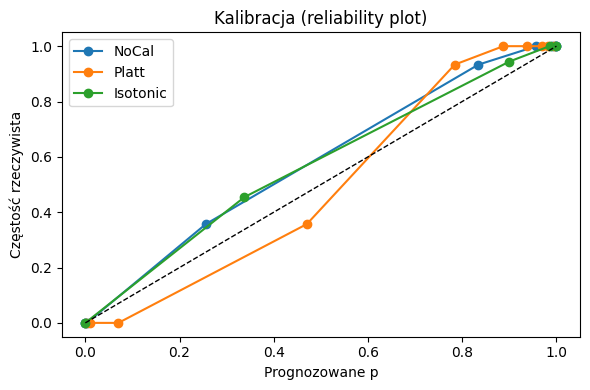

In [ ]:
# 6) Kalibracja: Platt i izotoniczna
platt = CalibratedClassifierCV(base, method="sigmoid",
cv=5).fit(Xtr, ytr)
iso = CalibratedClassifierCV(base, method="isotonic",
cv=5).fit(Xtr, ytr)
p_platt = platt.predict_proba(Xte)[:, 1]
p_iso = iso.predict_proba(Xte)[:, 1]
print("Platt Brier:", brier_score_loss(yte, p_platt))
print("Iso Brier:", brier_score_loss(yte, p_iso))

# 7) Krzywe kalibracji
fig, ax = plt.subplots(figsize=(6,4))
for name, p in [("NoCal", p_base), ("Platt", p_platt), ("Isotonic", p_iso)]:
    frac_pos, mean_pred = calibration_curve(yte, p, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel("Prognozowane p")
ax.set_ylabel("Częstość rzeczywista")
ax.set_title("Kalibracja (reliability plot)")
ax.legend(); plt.tight_layout(); plt.show()

### Interpretacja kalibracji i Brier score

Najlepszy wynik osiągnęła kalibracja izotoniczna, ponieważ uzyskała najniższy Brier score (`0.017`). Oznacza to, że przewidywane prawdopodobieństwa były najlepiej dopasowane do rzeczywistych częstości występowania klas.

Kalibracja Platta pogorszyła wynik względem modelu bazowego, co sugeruje, że w tym przypadku metoda sigmoid nie poprawiła jakości probabilistycznych predykcji.

Na wykresie kalibracji wszystkie modele znajdują się stosunkowo blisko przekątnej idealnej kalibracji, co oznacza ogólnie dobre dopasowanie przewidywanych prawdopodobieństw do rzeczywistości. Model izotoniczny przez większą część zakresu pozostaje bliżej linii idealnej kalibracji niż pozostałe modele.

In [4]:
# 8) Próg decyzyjny (Youden) – na izotonicznie skalibrowanym wariancie
fpr, tpr, thr = roc_curve(yte, p_iso)
best_idx = np.argmax(tpr - fpr)
thr_best = thr[best_idx]
print(f"Próg Youdena: {thr_best:.3f} (TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
yhat = (p_iso >= thr_best).astype(int)
print("Macierz pomyłek @Youden:\n", confusion_matrix(yte, yhat))

Próg Youdena: 0.457 (TPR=1.000, FPR=0.019)
Macierz pomyłek @Youden:
 [[52  1]
 [ 0 90]]


### Dobór progu decyzyjnego (Youden)

Macierz pomyłek:
- True negatives = 52
- False positives = 1
- False negatives = 0
- True positives = 90

Model przy tym progu praktycznie nie popełnia błędów typu II (FN = 0), co oznacza, że wszystkie przypadki pozytywne zostały wykryte. Jednocześnie był tylko jeden false positive, co świadczy o bardzo wysokiej precyzji.
Częściej więc popełnia błędy typu I (false positives).

In [5]:
# 9) Współczynniki i OR
lr = base.named_steps["lr"]
coefs = lr.coef_.ravel()
or_df = pd.DataFrame({
"cecha": X.columns,
"beta": coefs,
"odds_ratio": np.exp(coefs)
}).sort_values("odds_ratio", ascending=False)
print("\nTop ilorazy szans:\n", or_df.head(10).round(3))


Top ilorazy szans:
                       cecha   beta  odds_ratio
5          mean compactness  0.819       2.268
15        compactness error  0.619       1.857
18           symmetry error  0.443       1.557
19  fractal dimension error  0.362       1.437
11            texture error  0.222       1.248
16          concavity error  0.199       1.220
25        worst compactness  0.053       1.055
9    mean fractal dimension  0.024       1.024
8             mean symmetry -0.114       0.893
14         smoothness error -0.126       0.882


### Interpretacja współczynników regresji i ilorazów szans

Współczynniki regresji logistycznej zostały przekształcone do ilorazów szans (odds ratio), by móc je zinterpretować w kontekście wpływu cech na prawdopodobieństwo klasy pozytywnej.

Największy dodatni wpływ na predykcję mają cechy:
- mean compactness (OR = 2.268)
- compactness error (OR = 1.857)
- symmetry error (OR = 1.557)
- fractal dimension error (OR = 1.437)
- texture error (OR = 1.248)

Wartości OR > 1 oznaczają wzrost szansy klasy pozytywnej wraz ze wzrostem cechy, czyli np. wzrost mean compactness istotnie zwiększa ryzyko klasy pozytywnej.

Część cech ma wpływ ujemny (OR < 1), np. mean symmetry. Wzrost tych cech zmniejsza szansę wystąpienia klasy pozytywnej.

### Wnioski końcowe

**1. Kalibracja modelu**  
Model bazowy był już bardzo dobrze skalibrowany, co potwierdza niski Brier score (0.021). Kalibracja izotoniczna dodatkowo poprawiła jakość predykcji (miała najniższy Brier, 0.017), natomiast metoda Platta nie przyniosła poprawy.

**2. Najważniejsze cechy**  
Największy wpływ na decyzję modelu miały cechy związane z:
- compactness (zwartość ?)
- errorami (błędami pomiaru).

Szczególnie mean compactness oraz compactness error znacząco zwiększały szansę klasy pozytywnej.

**3. Dobór progu decyzyjnego**  
Próg Youdena (0.457) znacząco poprawił działanie modelu w sensie wykrywania przypadków pozytywnych - uzyskano pełną czułość (TPR = 1.0) przy bardzo niskim FPR (0.019). Model praktycznie nie pomija przypadków pozytywnych.

**4. Różnica między prawdopodobieństwem, odds i logit**  
- prawdopodobieństwo - jak często jest klasa pozytywna,
- odds - stosunek szans, ile razy bardziej prawdopodobne jest zajście zdarzenia niż jego brak,
- logit przekształca ten stosunek do skali (-∞, +∞).